# PySPEDAS pseudo variables

This notebook shows how to work with pseudo variables in PySPEDAS

The following line installs pyspedas, so this notebook can be used in Google Colab.  If you're running in an environment where pyspedas is already installed, you can comment out or skip this command.

In [1]:
!pip install pyspedas

In [2]:
import pyspedas

In [3]:
pyspedas.projects.mms.fpi(datatype='des-moms', trange=['2015-10-16', '2015-10-17'])
pyspedas.projects.mms.edp(trange=['2015-10-16', '2015-10-17'], datatype='scpot')

18-Dec-25 13:14:08: Loading files for group: probe: 1, drate: fast, level: l2, datatype: des-moms, after sorting and filtering:
18-Dec-25 13:14:08: pydata/mms1/fpi/fast/l2/des-moms/2015/10/mms1_fpi_fast_l2_des-moms_20151016040000_v3.4.0.cdf
18-Dec-25 13:14:08: pydata/mms1/fpi/fast/l2/des-moms/2015/10/mms1_fpi_fast_l2_des-moms_20151016060000_v3.4.0.cdf
18-Dec-25 13:14:08: pydata/mms1/fpi/fast/l2/des-moms/2015/10/mms1_fpi_fast_l2_des-moms_20151016080000_v3.4.0.cdf
18-Dec-25 13:14:08: pydata/mms1/fpi/fast/l2/des-moms/2015/10/mms1_fpi_fast_l2_des-moms_20151016100000_v3.4.0.cdf
18-Dec-25 13:14:08: pydata/mms1/fpi/fast/l2/des-moms/2015/10/mms1_fpi_fast_l2_des-moms_20151016120000_v3.4.0.cdf
18-Dec-25 13:14:08: pydata/mms1/fpi/fast/l2/des-moms/2015/10/mms1_fpi_fast_l2_des-moms_20151016140000_v3.4.0.cdf
18-Dec-25 13:14:08: pydata/mms1/fpi/fast/l2/des-moms/2015/10/mms1_fpi_fast_l2_des-moms_20151016160000_v3.4.0.cdf
18-Dec-25 13:14:09: Loading files for group: probe: 1, drate: fast, level: l2, da

['mms1_edp_dcv_fast_l2', 'mms1_edp_scpot_fast_l2', 'mms1_edp_psp_fast_l2']

Create a pseudo variable containing the perpendicular and parallel temperatures

In [4]:
from pyspedas import store_data

In [5]:
store_data('temp', data=['mms1_des_tempperp_fast', 'mms1_des_temppara_fast'])

True

Plot the pseudo variable

Note: by default, the figure uses the metadata from the first variable in the list

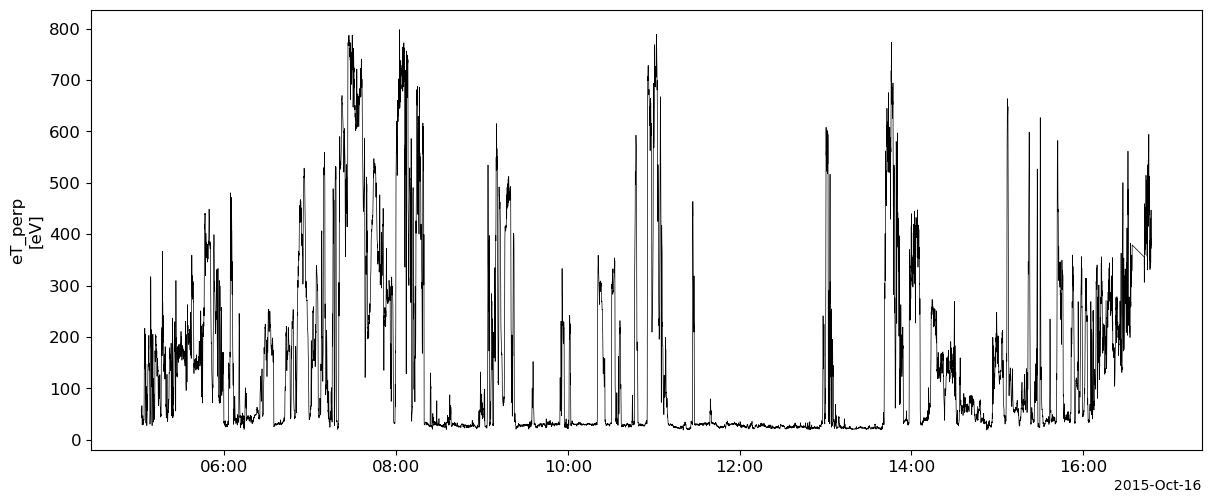

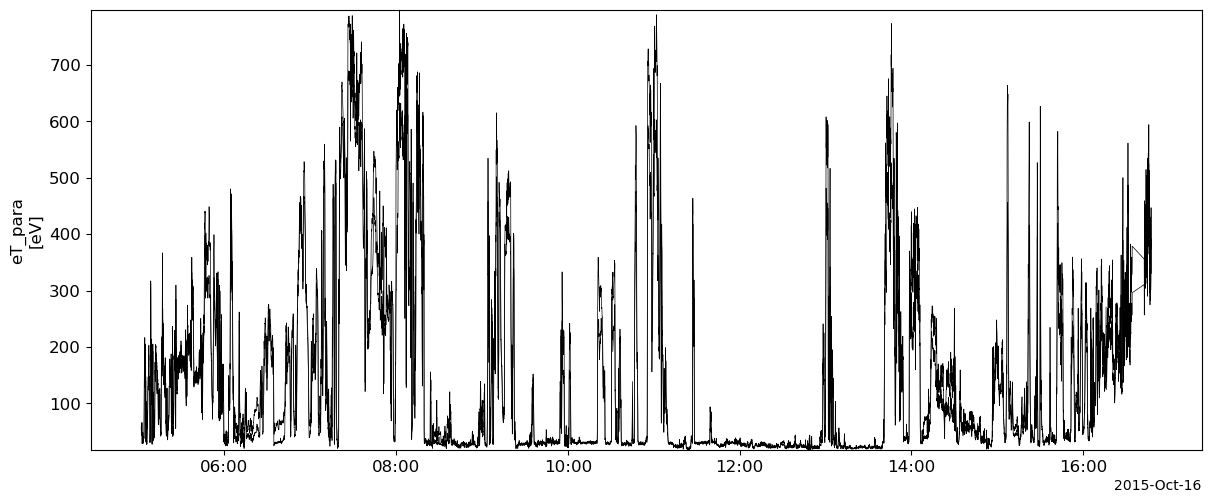

In [6]:
from pyspedas import tplot
from pyspedas import options
options('mms1_des_tempperp_fast','right_axis',True)
tplot('mms1_des_tempperp_fast')
tplot('temp')

The plot options can be updated just like a normal tplot variable

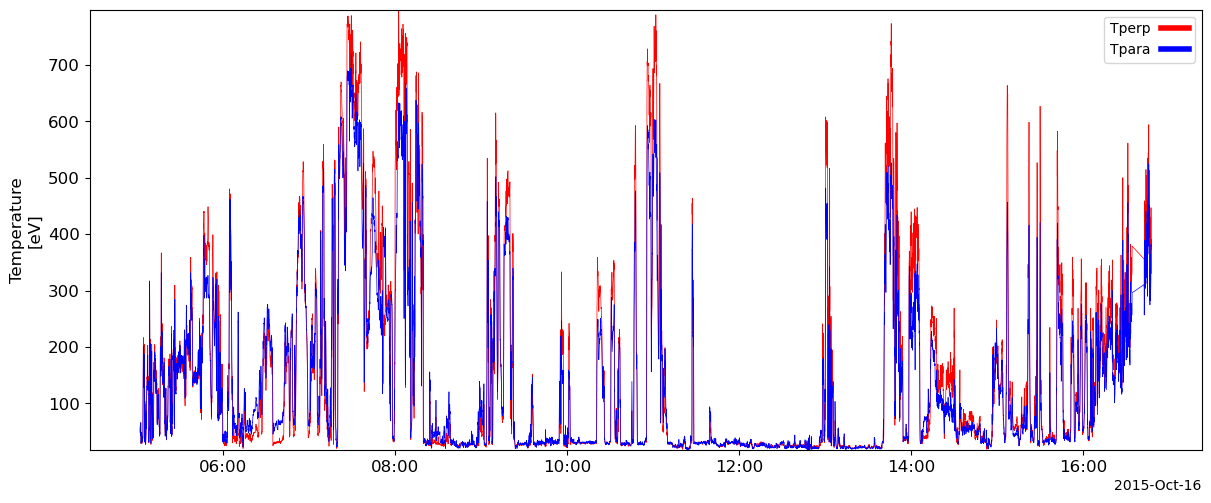

In [7]:
from pyspedas import options

options('temp', 'ytitle', 'Temperature')
options('temp', 'color', ['red', 'blue'])
options('temp', 'legend_names', ['Tperp', 'Tpara'])

tplot('temp')

Pseudo variables can be used to plot lines over spectrograms, e.g., to plot the spacecraft potential over the ion energy spectra:


In [8]:
store_data('spec', data=['mms1_des_energyspectr_omni_fast', 'mms1_edp_scpot_fast_l2'])

True

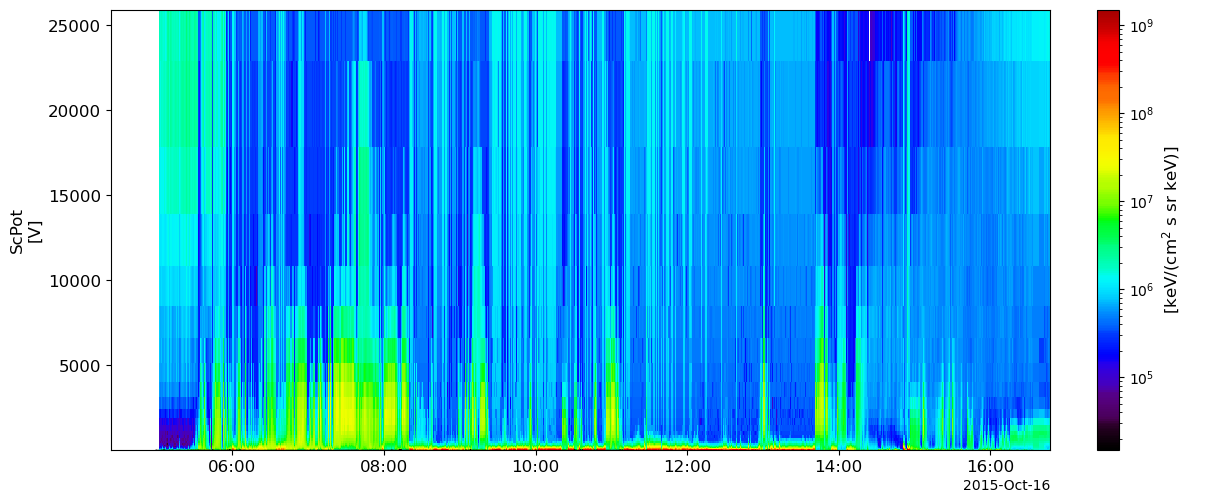

In [9]:
tplot('spec')

But the spacecraft potential isn't showing....what happened?

The spectral data has a large energy range, and at this scale the s/c potential is squashed along the bottom axis.
We can zoom in on the lower energies by setting a smaller yrange on the pseudovariable.

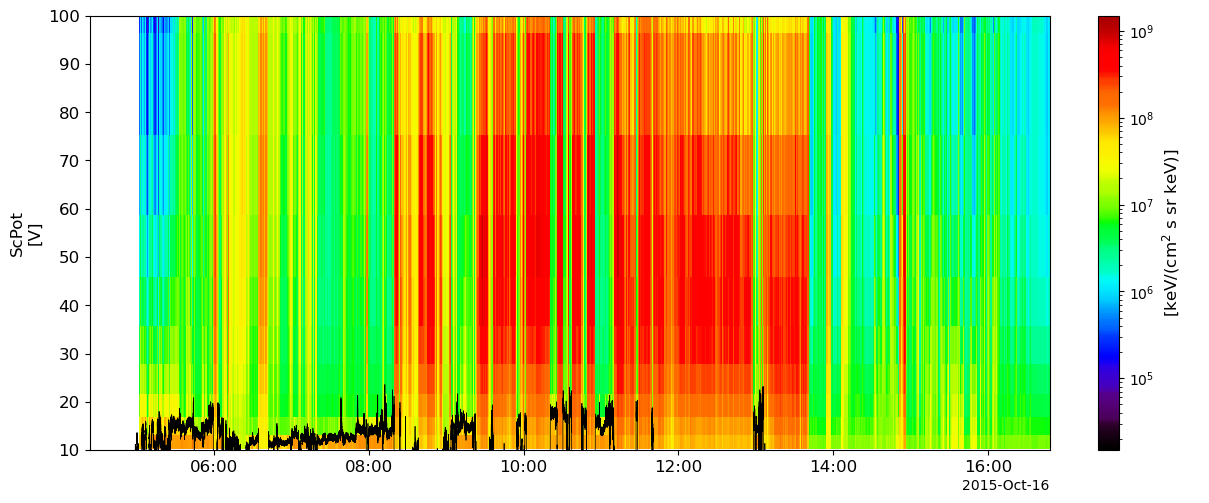

In [10]:
options('spec', 'yrange', [10, 100])

tplot('spec', xsize=12)

We can also make a pseudovariable with multiple spectra.  For this example, we'll combine THEMIS ESA and SST data, which are acquired at the same time, but have disjoint energy ranges.

In [11]:
# Load THEMIS particle data for ESA and SST instruments
pyspedas.projects.themis.esa(probe='a',trange=['2007-03-23','2007-03-24'])
pyspedas.projects.themis.sst(probe='a',trange=['2007-03-23','2007-03-24'])

18-Dec-25 13:14:14: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/esa/2007/
18-Dec-25 13:14:15: File is current: themis_data/tha/l2/esa/2007/tha_l2_esa_20070323_v01.cdf
18-Dec-25 13:14:15: Variable tha_peer_symm_angQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
18-Dec-25 13:14:15: Variable tha_peer_magfQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
18-Dec-25 13:14:15: Variable tha_peer_velocity_dslQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
18-Dec-25 13:14:15: Variable tha_peer_velocity_gseQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
18-Dec-25 13:14:15: Variable tha_peer_velocity_gsmQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
18-Dec-25 13:14:15: Variable tha_peer_modeQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
18-Dec-25 13:14:18: Downloading remote index: https://themis.ssl

['tha_psif_data_quality',
 'tha_psif_en_eflux',
 'tha_psif_density',
 'tha_psif_avgtemp',
 'tha_psif_vthermal',
 'tha_psif_sc_pot',
 'tha_psif_t3',
 'tha_psif_magt3',
 'tha_psif_ptens',
 'tha_psif_mftens',
 'tha_psif_flux',
 'tha_psif_symm',
 'tha_psif_symm_ang',
 'tha_psif_magf',
 'tha_psif_velocity_dsl',
 'tha_psif_velocity_gse',
 'tha_psif_velocity_gsm',
 'tha_psef_data_quality',
 'tha_psef_en_eflux',
 'tha_psef_density',
 'tha_psef_avgtemp',
 'tha_psef_vthermal',
 'tha_psef_sc_pot',
 'tha_psef_t3',
 'tha_psef_magt3',
 'tha_psef_ptens',
 'tha_psef_mftens',
 'tha_psef_flux',
 'tha_psef_symm',
 'tha_psef_symm_ang',
 'tha_psef_magf',
 'tha_psef_velocity_dsl',
 'tha_psef_velocity_gse',
 'tha_psef_velocity_gsm',
 'tha_pseb_data_quality',
 'tha_pseb_en_eflux',
 'tha_pseb_density',
 'tha_pseb_avgtemp',
 'tha_pseb_vthermal',
 'tha_pseb_sc_pot',
 'tha_pseb_t3',
 'tha_pseb_magt3',
 'tha_pseb_ptens',
 'tha_pseb_mftens',
 'tha_pseb_flux',
 'tha_pseb_symm',
 'tha_pseb_symm_ang',
 'tha_pseb_magf'

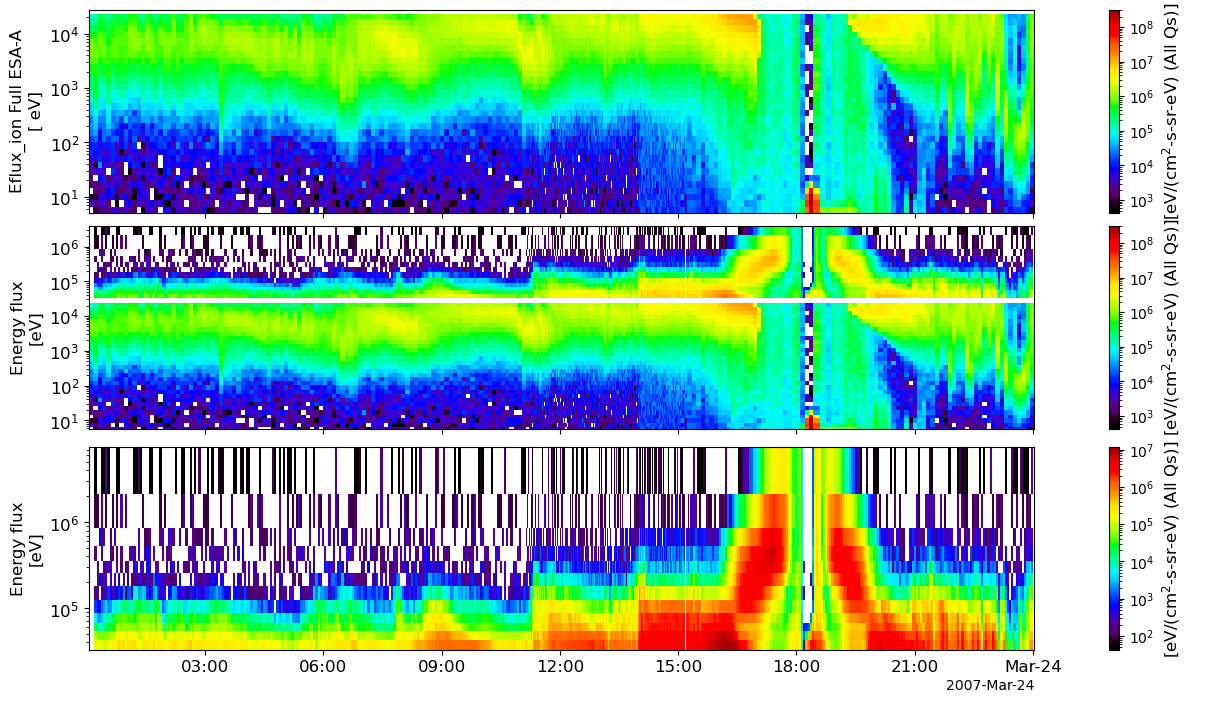

In [12]:
# Make a combined variable with both ESA and SST spectral data
store_data('combined_spec',['tha_peif_en_eflux','tha_psif_en_eflux'])
vars=['tha_peif_en_eflux','combined_spec', 'tha_psif_en_eflux']
tplot(vars)


We can also use pseudovariables to make a plot combining survey and burst data from the same instrument:

18-Dec-25 13:14:22: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 2643 of 3033 time indices.
18-Dec-25 13:14:22: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 2643 of 3033 time indices.


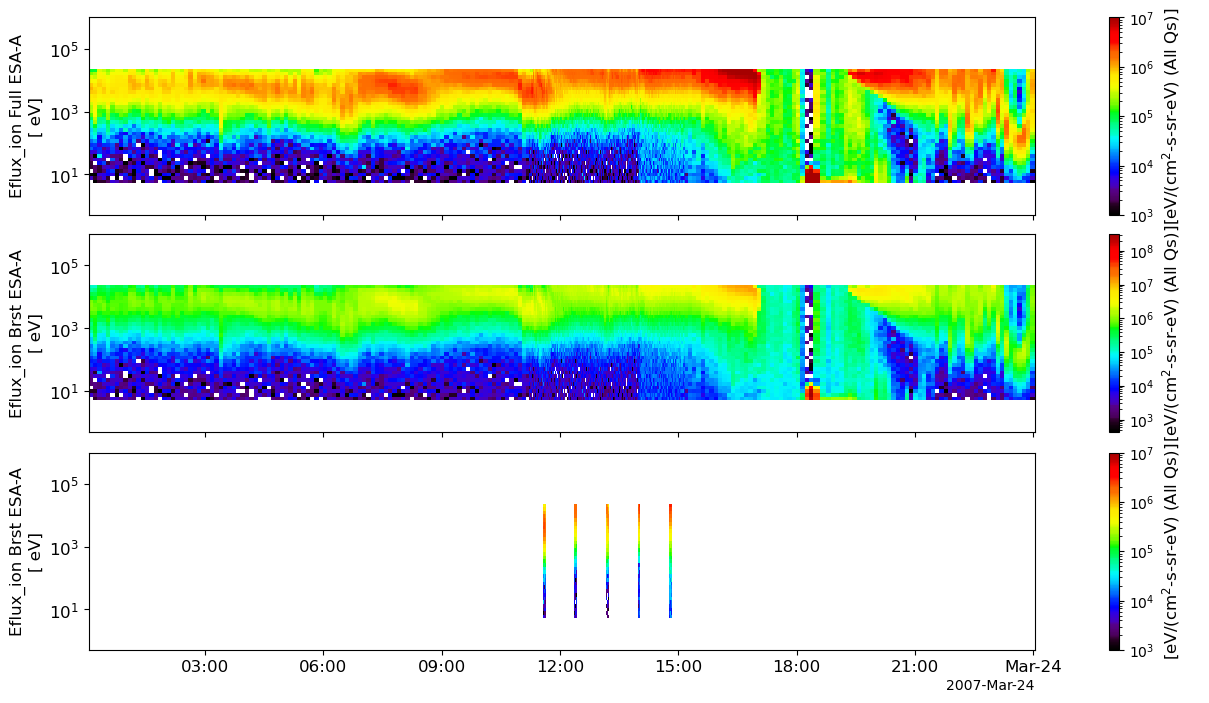

In [13]:
from pyspedas import zlim,ylim
store_data('esa_srvy_burst',['tha_peif_en_eflux','tha_peib_en_eflux'])
options('tha_peif_en_eflux','y_no_resample',1)
zlim('tha_peif_en_eflux',1.0e3,1.0e7)
options('tha_peif_en_eflux','y_range',[0.5,1.0e6])

options('tha_peib_en_eflux','y_no_resample',1)
zlim('tha_peib_en_eflux',1.0e3,1.0e7)
options('tha_peib_en_eflux','y_range',[0.5,1.0e6])
options('tha_peib_en_eflux','data_gap',4.0)
vars=['tha_peif_en_eflux','esa_srvy_burst','tha_peib_en_eflux']
tplot(vars)

Let's zoom in on one of the particle burst intervals.

18-Dec-25 13:14:23: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 91 of 169 time indices.
18-Dec-25 13:14:23: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 91 of 169 time indices.


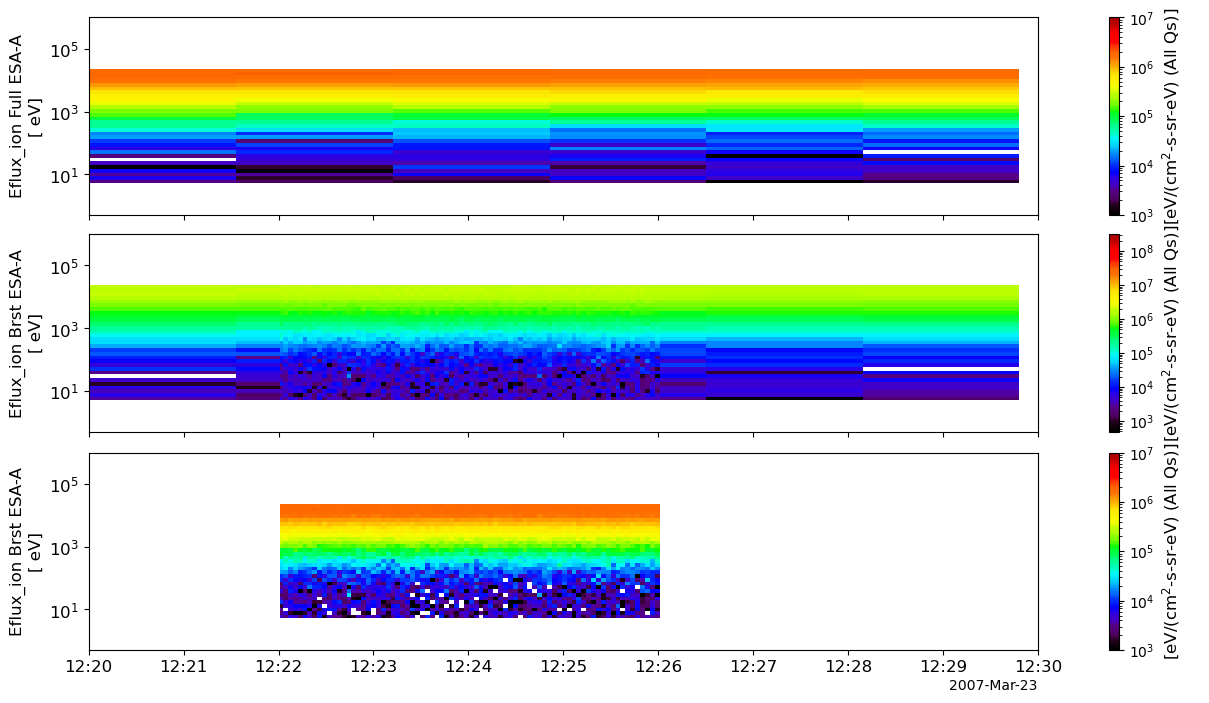

In [14]:
from pyspedas import timespan
timespan('2007-03-23/12:20',10,'minutes')
tplot(vars)

In [15]:
from pyspedas import get_data
atts=get_data('tha_peib_en_eflux',metadata=True)
print(atts)

{'CDF': {'VATT': {'DISPLAY_TYPE': 'spectrogram', 'FILLVAL': np.float64(nan), 'FORMAT': 'E13.6', 'DEPEND_TIME': 'tha_peib_time', 'DEPEND_EPOCH0': 'tha_peib_epoch0', 'DEPEND_0': 'tha_peib_epoch', 'VAR_TYPE': 'data', 'PROPERTY': 'spectrogram', 'SC_ID': 'a', 'CATDESC': '-----Ion Energy Flux spectrogram', 'FIELDNAM': 'Eflux_ion Brst ESA-A(all qualities)', 'VALIDMIN': np.float64(0.0), 'VALIDMAX': np.float64(10000000000.0), 'LABLAXIS': 'Eflux_ion Brst ESA-A', 'SCALETYP': 'log', 'UNITS': 'eV/(cm^2-s-sr-eV) (All Qs)', 'SI_CONVERSION': '1.0e4>J m^-2 s^-1 sr^-1 J^-1', 'COORDINATE_SYSTEM': 'DSL (Despun Spacecraft)', 'DEPEND_1': 'tha_peib_en_eflux_yaxis'}, 'GATT': {'Project': ['THEMIS'], 'Source_name': ['THA>Themis Probe A'], 'Discipline': ['Space Physics>Magnetospheric Science'], 'Data_type': ['ESA'], 'Descriptor': ['L2>L2 DATA'], 'Data_version': ['1'], 'PI_name': ['V. Angelopoulos, C.W. Carlson & J. McFadden'], 'PI_affiliation': ['UCB, NASA NAS5-02099'], 'TITLE': ['Electrostatic Analyzer (ESA)'],